# SECOM Dataset Exploration

**Project:** AIoT Predictive Maintenance for Semiconductor Test Equipment  
**Module:** LD7182 — AI for IoT  
**Author:** Rekhanth Reddy Obireddy  

## Goal
Understand the SECOM dataset structure, class imbalance, and missing
value characteristics before designing the preprocessing pipeline
for TinyML deployment on ESP32.

## Dataset Source
UCI Machine Learning Repository — SECOM Data Set  
https://archive.ics.uci.edu/dataset/179/secom

Original contributor: Michael McCann and Adrian Johnston (2008)

In [1]:
# Download SECOM dataset from UCI Machine Learning Repository
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.names

--2026-04-26 11:48:23--  https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘secom.data’

secom.data              [  <=>               ]   5.14M  12.5MB/s    in 0.4s    

2026-04-26 11:48:23 (12.5 MB/s) - ‘secom.data’ saved [5389983]

--2026-04-26 11:48:23--  https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘secom_labels.data’

secom_labels.data       [ <=>                ]  39.69K  --.-KB/s    in 0.05s   

2026-04-26 11:48:24 (769 KB/s) - ‘secom_labels.data’ sav

In [2]:
!ls -la *.data *.names

-rw-r--r-- 1 root root 5389983 Apr 26 11:48 secom.data
-rw-r--r-- 1 root root   40638 Apr 26 11:48 secom_labels.data
-rw-r--r-- 1 root root    4223 Apr 26 11:48 secom.names


## 1. Load the Dataset

The SECOM dataset has two files:
- `secom.data` — 1567 samples × 591 features (sensor readings from semiconductor manufacturing)
- `secom_labels.data` — Labels (+1 = pass, -1 = fail) with timestamps

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
# Load features (space-separated, no header)
# Missing values are represented as 'NaN' in the file
X = pd.read_csv('secom.data', sep=' ', header=None, na_values='NaN')

print(f"Features (X) shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

Features (X) shape: (1567, 590)
Number of samples: 1567
Number of features: 590


In [5]:
# Load labels (1 = pass, -1 = fail) and timestamps
y_raw = pd.read_csv('secom_labels.data', sep=' ', header=None,
                    names=['label', 'timestamp'])

# Extract just the labels
y = y_raw['label']

print(f"Labels shape: {y.shape}")
print(f"\nFirst 10 labels:")
print(y.head(10).values)
print(f"\nLabel data type: {y.dtype}")
print(f"Unique values: {y.unique()}")

Labels shape: (1567,)

First 10 labels:
[-1 -1  1 -1 -1 -1 -1 -1 -1 -1]

Label data type: int64
Unique values: [-1  1]


In [6]:
# Peek at the first 5 rows, first 8 features
print("First 5 rows, first 8 features:")
X.iloc[:5, :8]

First 5 rows, first 8 features:


,0,1,2,3,4,5,6,7
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235


## 2. Class Distribution and Imbalance

In SECOM, the labels are:
- **+1 = Pass** (manufacturing succeeded)
- **-1 = Fail** (manufacturing failed)

Real fab production data is heavily imbalanced because most products pass —
this is exactly why SECOM is challenging for ML.

In [10]:
# CORRECTED: SECOM convention
# -1 = Pass (1463 samples, ~93%)
# +1 = Fail (104 samples, ~7%)

# Recompute with correct labels
total = len(y)
pass_count = (y == -1).sum()  # -1 is pass
fail_count = (y == 1).sum()   # +1 is fail
pass_pct = pass_count / total * 100
fail_pct = fail_count / total * 100

print(f"=== Corrected SECOM Class Distribution ===")
print(f"Total samples: {total}")
print(f"Pass (-1): {pass_count} ({pass_pct:.2f}%)")
print(f"Fail (+1): {fail_count} ({fail_pct:.2f}%)")
print(f"\nImbalance ratio: 1 fail for every {pass_count / fail_count:.1f} passes")

=== Corrected SECOM Class Distribution ===
Total samples: 1567
Pass (-1): 1463 (93.36%)
Fail (+1): 104 (6.64%)

Imbalance ratio: 1 fail for every 14.1 passes


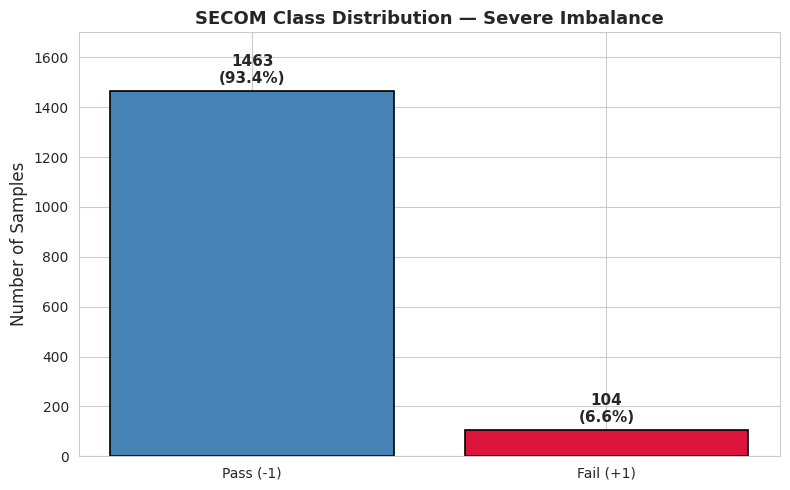


Figure saved (overwriting previous version)


In [12]:
# Corrected chart with proper SECOM convention
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'crimson']  # blue for pass, red for fail
bars = ax.bar(['Pass (-1)', 'Fail (+1)'],
              [pass_count, fail_count],
              color=colors, edgecolor='black', linewidth=1.2)

# Add count labels on top of bars
for bar, count in zip(bars, [pass_count, fail_count]):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('SECOM Class Distribution — Severe Imbalance',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1700)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved (overwriting previous version)")

### Observation: Why This Imbalance Matters

In SECOM, labels follow this convention:
- **-1 = Pass** (1463 samples, 93.36%)
- **+1 = Fail** (104 samples, 6.64%)

A naive classifier that always predicts "Pass" would achieve **93.36% accuracy**
on this dataset — but it would never catch a single fault. This makes accuracy
a misleading metric for SECOM.

**Implications for modeling:**
- Need to use F1-score, precision, recall (especially on the minority class)
- Confusion matrix is essential for honest evaluation
- Class imbalance handling required: SMOTE, class weights, or undersampling
- A 6.6% fail rate is realistic for semiconductor fabs but punishing for ML

## 3. Missing Values Analysis

SECOM features come from many different sensors, not all of which produced
readings for every sample. Missing values appear as NaN in the dataset.

We need to understand:
- How widespread is the missingness?
- Are some features so sparse they're useless?
- What's our strategy for handling missing data?

In [13]:
# Count missing values for each feature
missing_per_feature = X.isnull().sum()
missing_pct = missing_per_feature / X.shape[0] * 100

# Categorise features by missingness severity
no_missing = (missing_per_feature == 0).sum()
low_missing = ((missing_pct > 0) & (missing_pct < 10)).sum()
medium_missing = ((missing_pct >= 10) & (missing_pct < 50)).sum()
high_missing = ((missing_pct >= 50) & (missing_pct < 100)).sum()
all_missing = (missing_pct == 100).sum()

total_features = X.shape[1]

print(f"=== Missing Value Distribution Across {total_features} Features ===\n")
print(f"No missing values:         {no_missing:>3} ({no_missing/total_features*100:.1f}%)")
print(f"Low missing (<10%):        {low_missing:>3} ({low_missing/total_features*100:.1f}%)")
print(f"Medium missing (10-50%):   {medium_missing:>3} ({medium_missing/total_features*100:.1f}%)")
print(f"High missing (50-100%):    {high_missing:>3} ({high_missing/total_features*100:.1f}%)")
print(f"Completely missing (100%): {all_missing:>3} ({all_missing/total_features*100:.1f}%)")
print(f"\nTotal:                     {total_features}")

=== Missing Value Distribution Across 590 Features ===

No missing values:          52 (8.8%)
Low missing (<10%):        486 (82.4%)
Medium missing (10-50%):    24 (4.1%)
High missing (50-100%):     28 (4.7%)
Completely missing (100%):   0 (0.0%)

Total:                     590


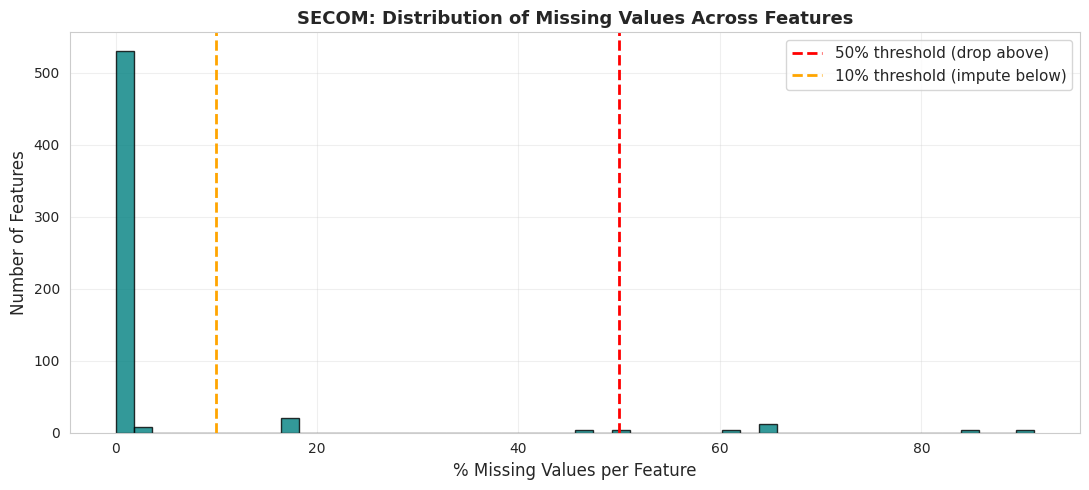


Figure saved as 'missing_values_distribution.png'


In [14]:
# Histogram of missingness percentage
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(missing_pct, bins=50, color='teal', edgecolor='black', alpha=0.8)
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='50% threshold (drop above)')
ax.axvline(10, color='orange', linestyle='--', linewidth=2, label='10% threshold (impute below)')

ax.set_xlabel('% Missing Values per Feature', fontsize=12)
ax.set_ylabel('Number of Features', fontsize=12)
ax.set_title('SECOM: Distribution of Missing Values Across Features',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_values_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'missing_values_distribution.png'")

In [15]:
# Total missing cells in the entire dataset
total_cells = X.shape[0] * X.shape[1]
total_missing = X.isnull().sum().sum()
missing_overall_pct = total_missing / total_cells * 100

print(f"=== Overall Dataset Completeness ===\n")
print(f"Total cells in matrix: {total_cells:,}")
print(f"Total missing cells:   {total_missing:,}")
print(f"Overall missingness:   {missing_overall_pct:.2f}%")
print(f"Overall completeness:  {100 - missing_overall_pct:.2f}%")

# Count rows with at least one missing value
rows_with_missing = (X.isnull().any(axis=1)).sum()
print(f"\nRows with ≥1 missing value: {rows_with_missing} of {X.shape[0]} ({rows_with_missing/X.shape[0]*100:.1f}%)")

=== Overall Dataset Completeness ===

Total cells in matrix: 924,530
Total missing cells:   41,951
Overall missingness:   4.54%
Overall completeness:  95.46%

Rows with ≥1 missing value: 1567 of 1567 (100.0%)


In [16]:
# Features to drop (>50% missing)
drop_candidates = missing_per_feature[missing_pct >= 50]

print(f"Features with ≥50% missing values (drop candidates):")
print(f"Count: {len(drop_candidates)}")
print(f"\nIf we drop these, we'd reduce features from {X.shape[1]} to {X.shape[1] - len(drop_candidates)}")

if len(drop_candidates) > 0:
    print(f"\nFirst 10 drop candidates (showing missing %):")
    sample = drop_candidates.head(10)
    for idx, count in sample.items():
        print(f"  Feature {idx}: {count}/{X.shape[0]} missing ({count/X.shape[0]*100:.1f}%)")

Features with ≥50% missing values (drop candidates):
Count: 28

If we drop these, we'd reduce features from 590 to 562

First 10 drop candidates (showing missing %):
  Feature 72: 794/1567 missing (50.7%)
  Feature 73: 794/1567 missing (50.7%)
  Feature 85: 1341/1567 missing (85.6%)
  Feature 109: 1018/1567 missing (65.0%)
  Feature 110: 1018/1567 missing (65.0%)
  Feature 111: 1018/1567 missing (65.0%)
  Feature 157: 1429/1567 missing (91.2%)
  Feature 158: 1429/1567 missing (91.2%)
  Feature 220: 1341/1567 missing (85.6%)
  Feature 244: 1018/1567 missing (65.0%)


### Observation: Missing Value Strategy

SECOM has a non-trivial amount of missing data, primarily because different
sensors in the manufacturing line don't always produce readings for every
process run.

**Preprocessing strategy decided:**

1. **Drop features with ≥50% missing** — these are too sparse to impute reliably
2. **Impute features with <50% missing** — use median imputation (robust to outliers)
3. **Do NOT drop rows** — we can't afford to lose samples given the imbalance
   (only 104 fail samples to begin with)
4. **Drop completely-missing features (100% missing)** — these are signal-free

**Why median over mean?**
SECOM features include many outliers (real sensor anomalies). Mean imputation
would distort the distribution; median is more robust.

## 4. Feature Variance and Scale Analysis

Beyond missing values, two more issues affect SECOM's feature quality:

1. **Constant features** — features with zero (or near-zero) variance carry
   no information and should be dropped
2. **Scale heterogeneity** — features measured in different units (temperature,
   pressure, flow rate, voltage) span many orders of magnitude, requiring
   standardisation before model training

In [17]:
# Compute variance, ignoring NaN
variance = X.var()

# Categorise by variance
zero_var = (variance == 0).sum()
near_zero_var = ((variance > 0) & (variance < 0.01)).sum()
low_var = ((variance >= 0.01) & (variance < 1)).sum()
normal_var = (variance >= 1).sum()
nan_var = variance.isnull().sum()  # features that are all-NaN

print(f"=== Variance Distribution ===\n")
print(f"Zero variance (constant):     {zero_var:>3} features")
print(f"Near-zero variance (<0.01):   {near_zero_var:>3} features")
print(f"Low variance (0.01 - 1):      {low_var:>3} features")
print(f"Normal variance (≥1):         {normal_var:>3} features")
print(f"All-NaN (no variance):        {nan_var:>3} features")
print(f"\nTotal: {X.shape[1]}")
print(f"\nDrop candidates (zero or near-zero variance): {zero_var + near_zero_var}")

=== Variance Distribution ===

Zero variance (constant):     116 features
Near-zero variance (<0.01):   160 features
Low variance (0.01 - 1):       69 features
Normal variance (≥1):         245 features
All-NaN (no variance):          0 features

Total: 590

Drop candidates (zero or near-zero variance): 276


In [18]:
# Look at the range of values across features
# Use describe() to get min, max, mean for the first 10 features
print("=== Sample of feature value ranges (first 10 features) ===\n")
sample_stats = X.iloc[:, :10].describe().T[['min', 'max', 'mean', 'std']]
print(sample_stats.round(3))

# Now check the overall scale spread across ALL features
print("\n\n=== Scale spread across ALL features ===\n")
feature_means = X.mean()
feature_stds = X.std()
feature_mins = X.min()
feature_maxs = X.max()

# Find the smallest and largest values in the entire dataset
overall_min = feature_mins.min()
overall_max = feature_maxs.max()

print(f"Smallest value anywhere in dataset: {overall_min:.6f}")
print(f"Largest value anywhere in dataset:  {overall_max:.2f}")
print(f"Smallest mean across features:      {feature_means.min():.6f}")
print(f"Largest mean across features:       {feature_means.max():.2f}")
print(f"Smallest std across features:       {feature_stds.min():.6f}")
print(f"Largest std across features:        {feature_stds.max():.2f}")

=== Sample of feature value ranges (first 10 features) ===

        min       max      mean      std
0  2743.240  3356.350  3014.453   73.622
1  2158.750  2846.440  2495.850   80.408
2  2060.660  2315.267  2200.547   29.513
3     0.000  3715.042  1396.377  441.692
4     0.682  1114.537     4.197   56.356
5   100.000   100.000   100.000    0.000
6    82.131   129.252   101.113    6.237
7     0.000     0.129     0.122    0.009
8     1.191     1.656     1.463    0.074
9    -0.053     0.075    -0.001    0.015


=== Scale spread across ALL features ===

Smallest value anywhere in dataset: -14804.500000
Largest value anywhere in dataset:  37943.00
Smallest mean across features:      -5618.393610
Largest mean across features:       8827.54
Smallest std across features:       0.000000
Largest std across features:        6553.57


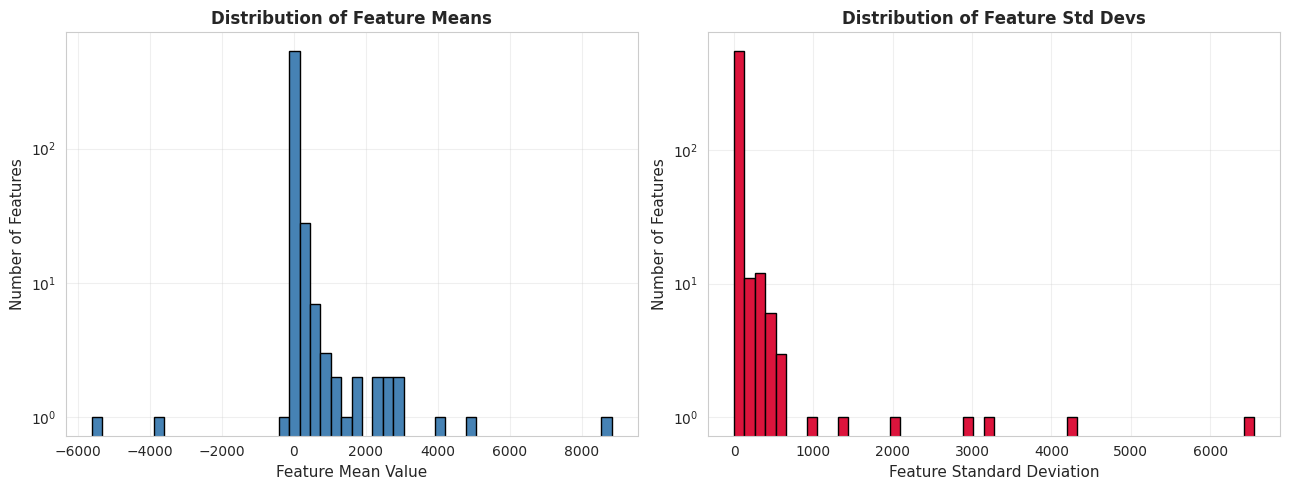


Figure saved as 'feature_scale_distribution.png'


In [19]:
# Box plot of feature means (log scale because the spread is huge)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Distribution of feature means
axes[0].hist(feature_means.dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Feature Mean Value', fontsize=11)
axes[0].set_ylabel('Number of Features', fontsize=11)
axes[0].set_title('Distribution of Feature Means', fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of feature standard deviations
axes[1].hist(feature_stds.dropna(), bins=50, color='crimson', edgecolor='black')
axes[1].set_xlabel('Feature Standard Deviation', fontsize=11)
axes[1].set_ylabel('Number of Features', fontsize=11)
axes[1].set_title('Distribution of Feature Std Devs', fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_scale_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'feature_scale_distribution.png'")

### Observation: Scale Heterogeneity Mandates Standardisation

SECOM features span **multiple orders of magnitude** in their value ranges.
This is because they originate from many different sensors measuring
different physical quantities (temperatures in Kelvin, pressures in millibars,
voltages in millivolts, flow rates, etc.).

**Without standardisation:**
- Features with large absolute values would dominate gradient updates
- Features with small values would be effectively ignored
- Distance-based methods (kNN, SVM with RBF) would fail entirely

**Decision: Apply z-score standardisation** (StandardScaler from scikit-learn)
to all features after imputation. This rescales each feature to have mean=0
and standard deviation=1.

**Note:** Standardisation must be fit on training data only, then applied to
test data — to avoid data leakage. This will be implemented in the
preprocessing pipeline next session.

## 5. Summary of Findings

### Dataset Overview
- **Source:** UCI Machine Learning Repository (McCann & Johnston, 2008)
- **Domain:** Semiconductor manufacturing process monitoring
- **Samples:** 1567
- **Features:** 590 (sensor readings)
- **Target:** Binary classification — pass (-1) vs fail (+1)

### Class Imbalance
- Pass (-1): 1463 samples (93.36%)
- Fail (+1): 104 samples (6.64%)
- Imbalance ratio: 1 fail per 14 passes

A naive "always pass" classifier would achieve 93.4% accuracy, making
accuracy a misleading metric. Evaluation must use F1-score, precision,
recall (especially on the minority class), and confusion matrix.

### Data Quality Issues

**Missing values:**
- Overall: 4.54% of cells are missing
- 100% of rows have ≥1 missing value (row-deletion not viable)
- 28 features (4.7%) have ≥50% missing values → drop
- 24 features (4.1%) have 10–50% missing → impute with median
- 538 features (91.2%) have <10% missing → impute with median

**Variance:**
- 116 features (19.7%) have zero variance (constant values)
- 160 features (27.1%) have near-zero variance (<0.01)
- Together, **276 features (46.8%) carry no useful information** → drop
- These are likely setpoint sensors (e.g., a temperature held at a
  constant control value)

**Scale heterogeneity:**
- Feature values span 4+ orders of magnitude
- Smallest value: -14,804; largest value: 37,943
- Standard deviations range from 0.000 to 6,553
- Without standardisation, large-magnitude features would dominate model
  training and small-magnitude features would be ignored

### Preprocessing Strategy

Based on the above analysis, the preprocessing pipeline will:

1. **Drop high-missing features** (≥50% missing): 28 features removed
2. **Drop constant/near-constant features** (variance < 0.01): up to 276
   features removed (with possible overlap with step 1)
3. **Median imputation** for remaining features with missing values
4. **Standardisation** (z-score, mean=0 std=1) using StandardScaler
5. **Class imbalance handling** during training: SMOTE or class_weight
   parameter (final choice TBD based on validation performance)

Expected feature count after preprocessing: ~280–300 (down from 590).

This is still too many for direct ESP32 deployment (the device has 520KB
SRAM). Further dimensionality reduction will be applied in the modeling
phase, targeting ~20–50 final features through:
- Correlation filtering (drop one of each highly-correlated pair)
- Feature importance ranking from a baseline tree model
- Possibly PCA for the final compression step

### Connection to Project Goals

This dataset's challenges — high dimensionality, severe class imbalance,
extensive missing values, scale heterogeneity, and substantial uninformative
content — represent realistic conditions in semiconductor manufacturing.
The constraints differ markedly from the simpler vibration datasets used
in prior TinyML PdM work (Gupta & Shivhare, 2025) or the audio-based
datasets reviewed in Njor et al. (2024).

The deployment of a SECOM-trained classifier on a resource-constrained
ESP32 microcontroller is therefore non-trivial and addresses a genuine
gap identified in the literature.

## Next Steps

This exploration notebook informs the preprocessing pipeline implemented
in `02_secom_preprocessing.ipynb` (next session). Subsequent notebooks
will cover model training, quantisation, and TFLite conversion for ESP32
deployment.